In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt,welch
from sklearn.preprocessing import MinMaxScaler
import os
from scipy.stats import gaussian_kde
import seaborn as sns

In [2]:
directory_name = input('CSV File Directory:')

In [3]:
# Navigate to the csv files directory
os.chdir(directory_name)

In [4]:
# current directory csv files
csvs = [x for x in os.listdir(directory_name) if x.endswith('.csv')]
# stats.csv -> stats
fns = [os.path.splitext(os.path.basename(x))[0] for x in csvs]

dic_csv = {}
for i in range(len(fns)):
    dic_csv[fns[i]] = pd.read_csv(csvs[i])

In [8]:
dic_csv['02_P1_20_100-50_Cracked Diaphragm'].columns

Index(['Time', 'Cycle-detect', 'P1-CPM', 'Left-Vibration-Data',
       'P1-Water Discharge Pressure', 'P1-Air-Supply-pressure',
       'P1-Air Supply Flowrate'],
      dtype='object')

In [7]:
dic_csv['02_P1_20_100-50_Cracked Diaphragm'].rename(columns={'Right-Vibration-Data':'Left-Vibration-Data'},inplace=True)

In [18]:
Vib_good =  pd.DataFrame(dic_csv['01_P2_20_100-50_Good Diaphragm'],columns=['Left-Vibration-Data'])

In [19]:
Vib_cracked = pd.DataFrame(dic_csv['02_P1_20_100-50_Cracked Diaphragm'],columns=['Left-Vibration-Data'])

In [22]:
Vib_good

,Left-Vibration-Data
0,0.000000
1,0.000000
2,0.000000
3,0.000000
4,2.267413
...,...
848387,2.259672
848388,2.258382
848389,2.260962
848390,2.262252


In [21]:
Vib_cracked

,Left-Vibration-Data
0,0.000000
1,0.000000
2,0.000000
3,0.000000
4,1.010104
...,...
1238136,1.010104
1238137,1.007528
1238138,1.006240
1238139,1.006240


In [ ]:
Vib_good.info()

In [28]:
vib_data

,Left-Vibration-Data
0,0.000000
1,0.000000
2,0.000000
3,0.000000
4,2.267413
...,...
2086528,1.010104
2086529,1.007528
2086530,1.006240
2086531,1.006240


In [ ]:
vib_data.info()

In [48]:
#outlier analysis
q1 = Vib_good['Left-Vibration-Data'].quantile(0.25)
q3 = Vib_good['Left-Vibration-Data'].quantile(0.75)
IQR = q3 - q1
upper_limit = q3 + (1.5 * IQR)   
lower_limit = q1 - (1.5 * IQR)
Vib_good_clean = Vib_good[(Vib_good['Left-Vibration-Data']<upper_limit)&(Vib_good['Left-Vibration-Data']>lower_limit)]
Vib_good_clean.reset_index(drop=True,inplace=True)

In [49]:
#outlier analysis
q1 = Vib_cracked['Left-Vibration-Data'].quantile(0.25)
q3 = Vib_cracked['Left-Vibration-Data'].quantile(0.75)
IQR = q3 - q1
upper_limit = q3 + (1.5 * IQR)   
lower_limit = q1 - (1.5 * IQR)
Vib_cracked_clean = Vib_cracked[(Vib_cracked['Left-Vibration-Data']<upper_limit)&(Vib_cracked['Left-Vibration-Data']>lower_limit)]
Vib_cracked_clean.reset_index(drop=True,inplace=True)

In [51]:
clean_vibration_dat = pd.concat([Vib_good_clean,Vib_cracked_clean],ignore_index=True)

In [48]:
def df_cleaning(datframe):
    print("Infinity values\n",np.isinf(datframe).sum())
    print("NaN values\n",datframe.isna().sum())
    print("Null vlaues\n",datframe.isnull().sum())
    return df_cleaning

In [ ]:
df_cleaning(clean_vibration_dat)

In [ ]:
len(clean_vibration_dat)

In [52]:
clean_vibration_dat.head()

,Left-Vibration-Data
0,2.267413
1,2.266123
2,2.266123
3,2.266123
4,2.262252


In [64]:
#Create timestamp column with sampling frequency 
Vib_good_clean['Timestamp'] = pd.date_range('2024-08-13 00:00:00', freq='30ms', periods=len(Vib_good_clean))
#Convert timestamp data type object in to datetime
Vib_good_clean['Timestamp'] =pd.to_datetime(Vib_good_clean['Timestamp'])
#Set timestamp as index
Vib_good_clean.set_index(['Timestamp'], inplace=True)

C:\Users\Admin\AppData\Local\Temp\ipykernel_13716\2348649838.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Vib_good_clean['Timestamp'] = pd.date_range('2024-08-13 00:00:00', freq='30ms', periods=len(Vib_good_clean))
C:\Users\Admin\AppData\Local\Temp\ipykernel_13716\2348649838.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Vib_good_clean['Timestamp'] =pd.to_datetime(Vib_good_clean['Timestamp'])


In [66]:
#Create timestamp column with sampling frequency 
Vib_cracked_clean['Timestamp'] = pd.date_range('2024-08-13 06:37:14.160', freq='30ms', periods=len(Vib_cracked_clean))
#Convert timestamp data type object in to datetime
Vib_cracked_clean['Timestamp'] =pd.to_datetime(Vib_cracked_clean['Timestamp'])
#Set timestamp as index
Vib_cracked_clean.set_index(['Timestamp'], inplace=True)

C:\Users\Admin\AppData\Local\Temp\ipykernel_13716\1456688010.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Vib_cracked_clean['Timestamp'] = pd.date_range('2024-08-13 06:37:14.160', freq='30ms', periods=len(Vib_cracked_clean))
C:\Users\Admin\AppData\Local\Temp\ipykernel_13716\1456688010.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Vib_cracked_clean['Timestamp'] =pd.to_datetime(Vib_cracked_clean['Timestamp'])


In [67]:
Vib_cracked_clean

,Left-Vibration-Data
Timestamp,
2024-08-13 06:37:14.160,1.010104
2024-08-13 06:37:14.190,1.010104
2024-08-13 06:37:14.220,1.008816
2024-08-13 06:37:14.250,1.010104
2024-08-13 06:37:14.280,1.010104
...,...
2024-08-13 16:39:47.760,1.010104
2024-08-13 16:39:47.790,1.007528
2024-08-13 16:39:47.820,1.006240


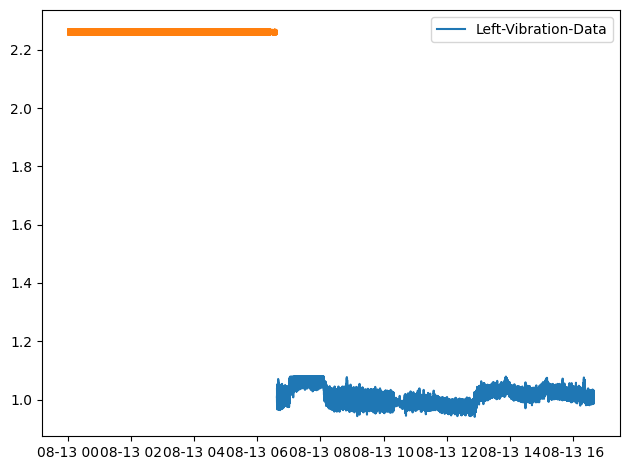

In [69]:
#plt.plot(cylinder_1_df.index, cylinder_1_df['PresTrans1'])
plt.plot(Vib_cracked_clean.index, Vib_cracked_clean['Left-Vibration-Data'])
plt.plot(Vib_good_clean.index, Vib_good_clean['Left-Vibration-Data'])
plt.legend(['Left-Vibration-Data'])
plt.tight_layout()

In [ ]:
clean_vibration_dat.head()

In [ ]:
# Step 2: Define the high-pass filter
def high_pass_filter(data, cutoff, fs, order=5):
    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist
    b, a = butter(order,normal_cutoff, btype='high', analog=False)
    y = filtfilt(b, a, data)
    return y

In [70]:
# Parameters for the high-pass filter
cutoff_frequency = 0.5  # Hz 
sampling_rate = 33.3  # Hz (adjust according to your actual sampling rate)
filtered_data_good = high_pass_filter(Vib_good_clean.iloc[:,0], cutoff_frequency, sampling_rate)

In [71]:
# Parameters for the high-pass filter
cutoff_frequency = 0.5  # Hz 
sampling_rate = 33.3  # Hz (adjust according to your actual sampling rate)
filtered_data_cracked = high_pass_filter(Vib_cracked_clean.iloc[:,0], cutoff_frequency, sampling_rate)

In [72]:
Filter_data_df_good = pd.DataFrame(filtered_data_good,columns=['Left-Vibration-Data'])

Filter_data_df_good['newtime'] = pd.date_range('2024-09-13 00:00:00.000000', freq='30ms', periods=len(Filter_data_df_good))

Filter_data_df_good['newtime'] = pd.to_datetime(Filter_data_df_good['newtime'])

Filter_data_df_good.set_index(['newtime'], inplace=True)

In [75]:
Filter_data_df_cracked = pd.DataFrame(filtered_data_cracked,columns=['Left-Vibration-Data'])
Filter_data_df_cracked['newtime'] = pd.date_range('2024-09-13 06:37:14.160', freq='30ms', periods=len(Filter_data_df_cracked))

Filter_data_df_cracked['newtime'] =pd.to_datetime(Filter_data_df_cracked['newtime'])

Filter_data_df_cracked.set_index(['newtime'], inplace=True)

In [112]:
Filter_data_df_cracked['Timeline'] = np.linspace(6.6,16.6,len(Filter_data_df_cracked))

In [113]:
Filter_data_df_good['Timeline'] = np.linspace(0,6.6,len(Filter_data_df_good))

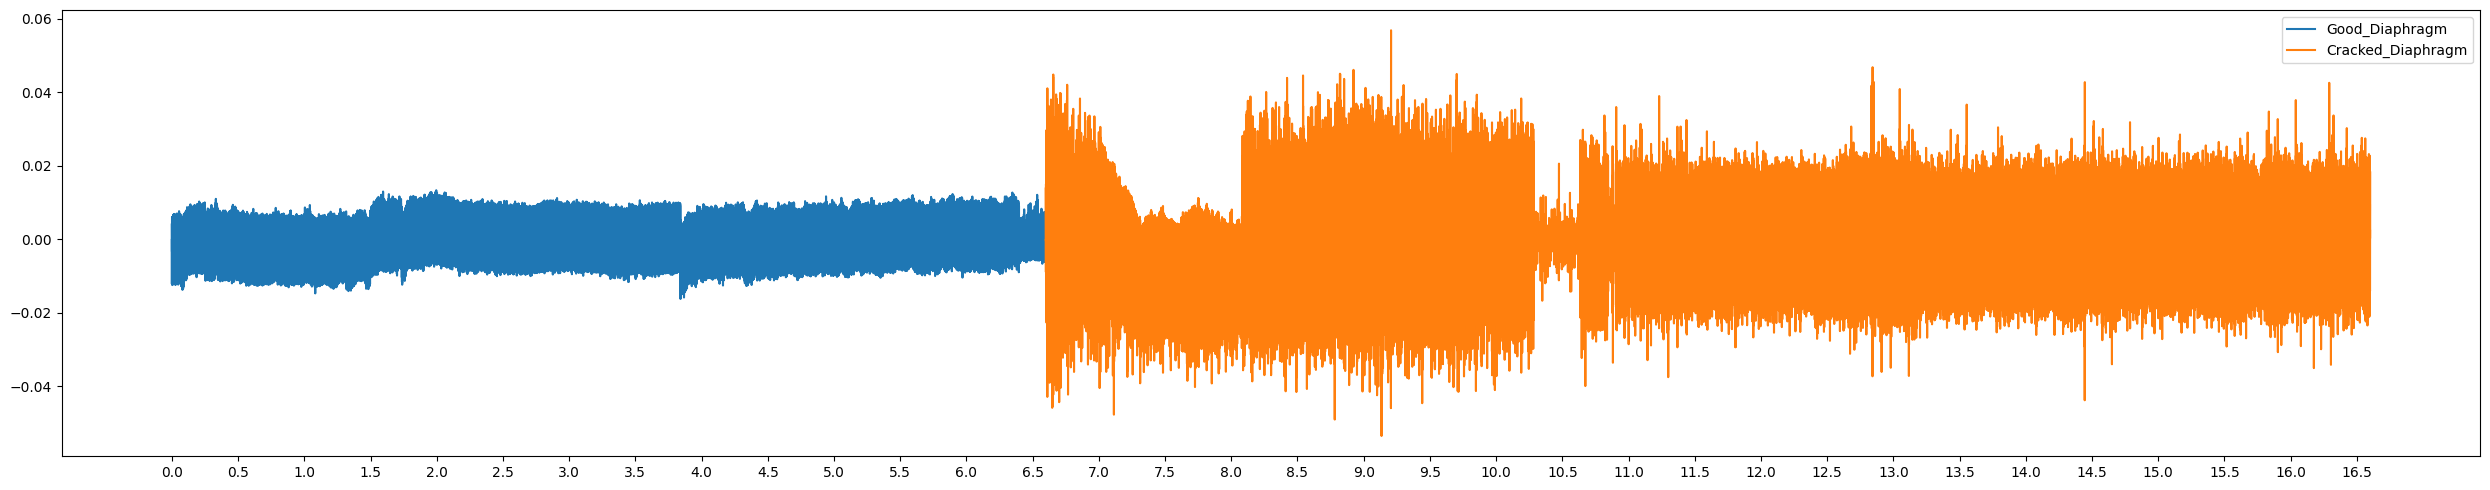

In [115]:
plt.figure(figsize=(25,5))
#plt.plot(cylinder_1_df.index, cylinder_1_df['PresTrans1'])
plt.plot(Filter_data_df_good['Timeline'], Filter_data_df_good['Left-Vibration-Data'])
plt.plot(Filter_data_df_cracked['Timeline'], Filter_data_df_cracked['Left-Vibration-Data'])
plt.legend(['Good_Diaphragm', 'Cracked_Diaphragm'])
plt.xticks(np.arange(0,17,0.5))
plt.tight_layout()


In [81]:
total_hrs_good=0
hrs=np.round((((Filter_data_df_good.index[-1]-Filter_data_df_good.index[0]).total_seconds())/3600),decimals=1)
total_hrs_good=total_hrs_good+hrs
total_hrs_good

6.6

In [82]:
total_hrs_cracked=0
hrs=np.round((((Filter_data_df_cracked.index[-1]-Filter_data_df_cracked.index[0]).total_seconds())/3600),decimals=1)
total_hrs_cracked=total_hrs_cracked+hrs
total_hrs_cracked

10.0

# FFT Analysis

In [38]:
# Function to apply a high-pass filter
def high_pass_filter(data, cutoff, fs, order=5):
    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist
    b, a = butter(order, normal_cutoff, btype='high', analog=False)
    filtered_data = filtfilt(b, a, data)
    return filtered_data

In [39]:

#temp_dic = {}
Freq_list = [] 
Amp_list = []
Freq_Amp_df = pd.DataFrame(columns=['Freq','Amp'])

start_time = Filter_data_df.index[0]
end_time = Filter_data_df.index[-1]
time_interval = pd.Timedelta(minutes=2)

current_time = start_time
while current_time <= end_time:
    
    next_time = current_time + time_interval
    
    # Slice the DataFrame based on the specified time range
    sliced_df = Filter_data_df.iloc[(Filter_data_df.index >= current_time) & (Filter_data_df.index <= next_time)]
    
    # Perform FFT analysis only if there is data in the sliced DataFrame
    n = len(sliced_df)
    if n > 0:
        t = sliced_df.index
        s = sliced_df['Left-Vibration-Data']

        # Apply high-pass filter
        dt = (t[1] - t[0]).total_seconds()  # Sampling interval in seconds
        

        # FFT
        s -= s.mean()
        fr = np.fft.rfftfreq(n, dt)
        fou = np.fft.rfft(s)
        
        # Create a DataFrame for the current fr,amp
        temp_df = pd.DataFrame({'Frequency': fr,'Amplitude': np.abs(fou)})

        #Filter max apllitude frim temp_df and put it in to df_filter
        df_Filter = temp_df.loc[temp_df['Amplitude'].idxmax()]
   
        #Append coresponding maximum amplitude frequency values in to freq_amp list
        Freq_list.append((df_Filter['Frequency']))
        
        Amp_list.append((df_Filter['Amplitude']))
                 
    else:
        pass
    current_time = next_time    
#temp_dic[key] = result_df

# Append the DataFrame to the list
Freq_Amp_df = pd.DataFrame({'Freq':Freq_list,'Amp':Amp_list})

In [ ]:
Freq_Amp_df=Freq_Amp_df[Freq_Amp_df['Freq']>0.03]

In [40]:
#Reset the data frame
Freq_Amp_df.reset_index(drop=True,inplace=True)

#Normalize the data frame values
normalized_variables = MinMaxScaler().fit_transform(Freq_Amp_df)

#Insert the normalized vaules in to the new columns
for value_index,col_name in enumerate(Freq_Amp_df.columns):
    Freq_Amp_df["Norm_{}".format(col_name)] = normalized_variables[:,value_index]

#Create Diaprhagm liftime
timeline = [n for n in np.linspace(0,total_hrs,len(Freq_Amp_df))]

#Insert timeline in to dataframe
Freq_Amp_df['Diaphragm_life'] = timeline

#Set Diaphragm life as index
Freq_Amp_df.set_index(['Diaphragm_life'],inplace=True)

In [41]:
def plot_funtion(dataframe):
    a = len(dataframe.columns)  # number of rows
    b = 1  # number of columns
    c = 1  # initialize plot counter
    fig1 = plt.figure(figsize=(35,20))
       
    for i in dataframe.columns:
        # Create a subplot and save the plot
        plt.subplot(a, b, c)
        plt.plot(dataframe.index, dataframe[i],marker = '.')
        plt.xticks(np.arange(np.min(dataframe.index),np.max((dataframe.index)),0.2))             
        #plt.ylim(0,0.5)
        plt.title(f"{i}{' vs Diaphragm Life Time'}")
        #plt.legend(df.columns, loc='lower center', bbox_to_anchor=(0.5, -0.14), ncol=8)
        c = c + 1
    return plot_funtion

<function __main__.plot_funtion(dataframe)>

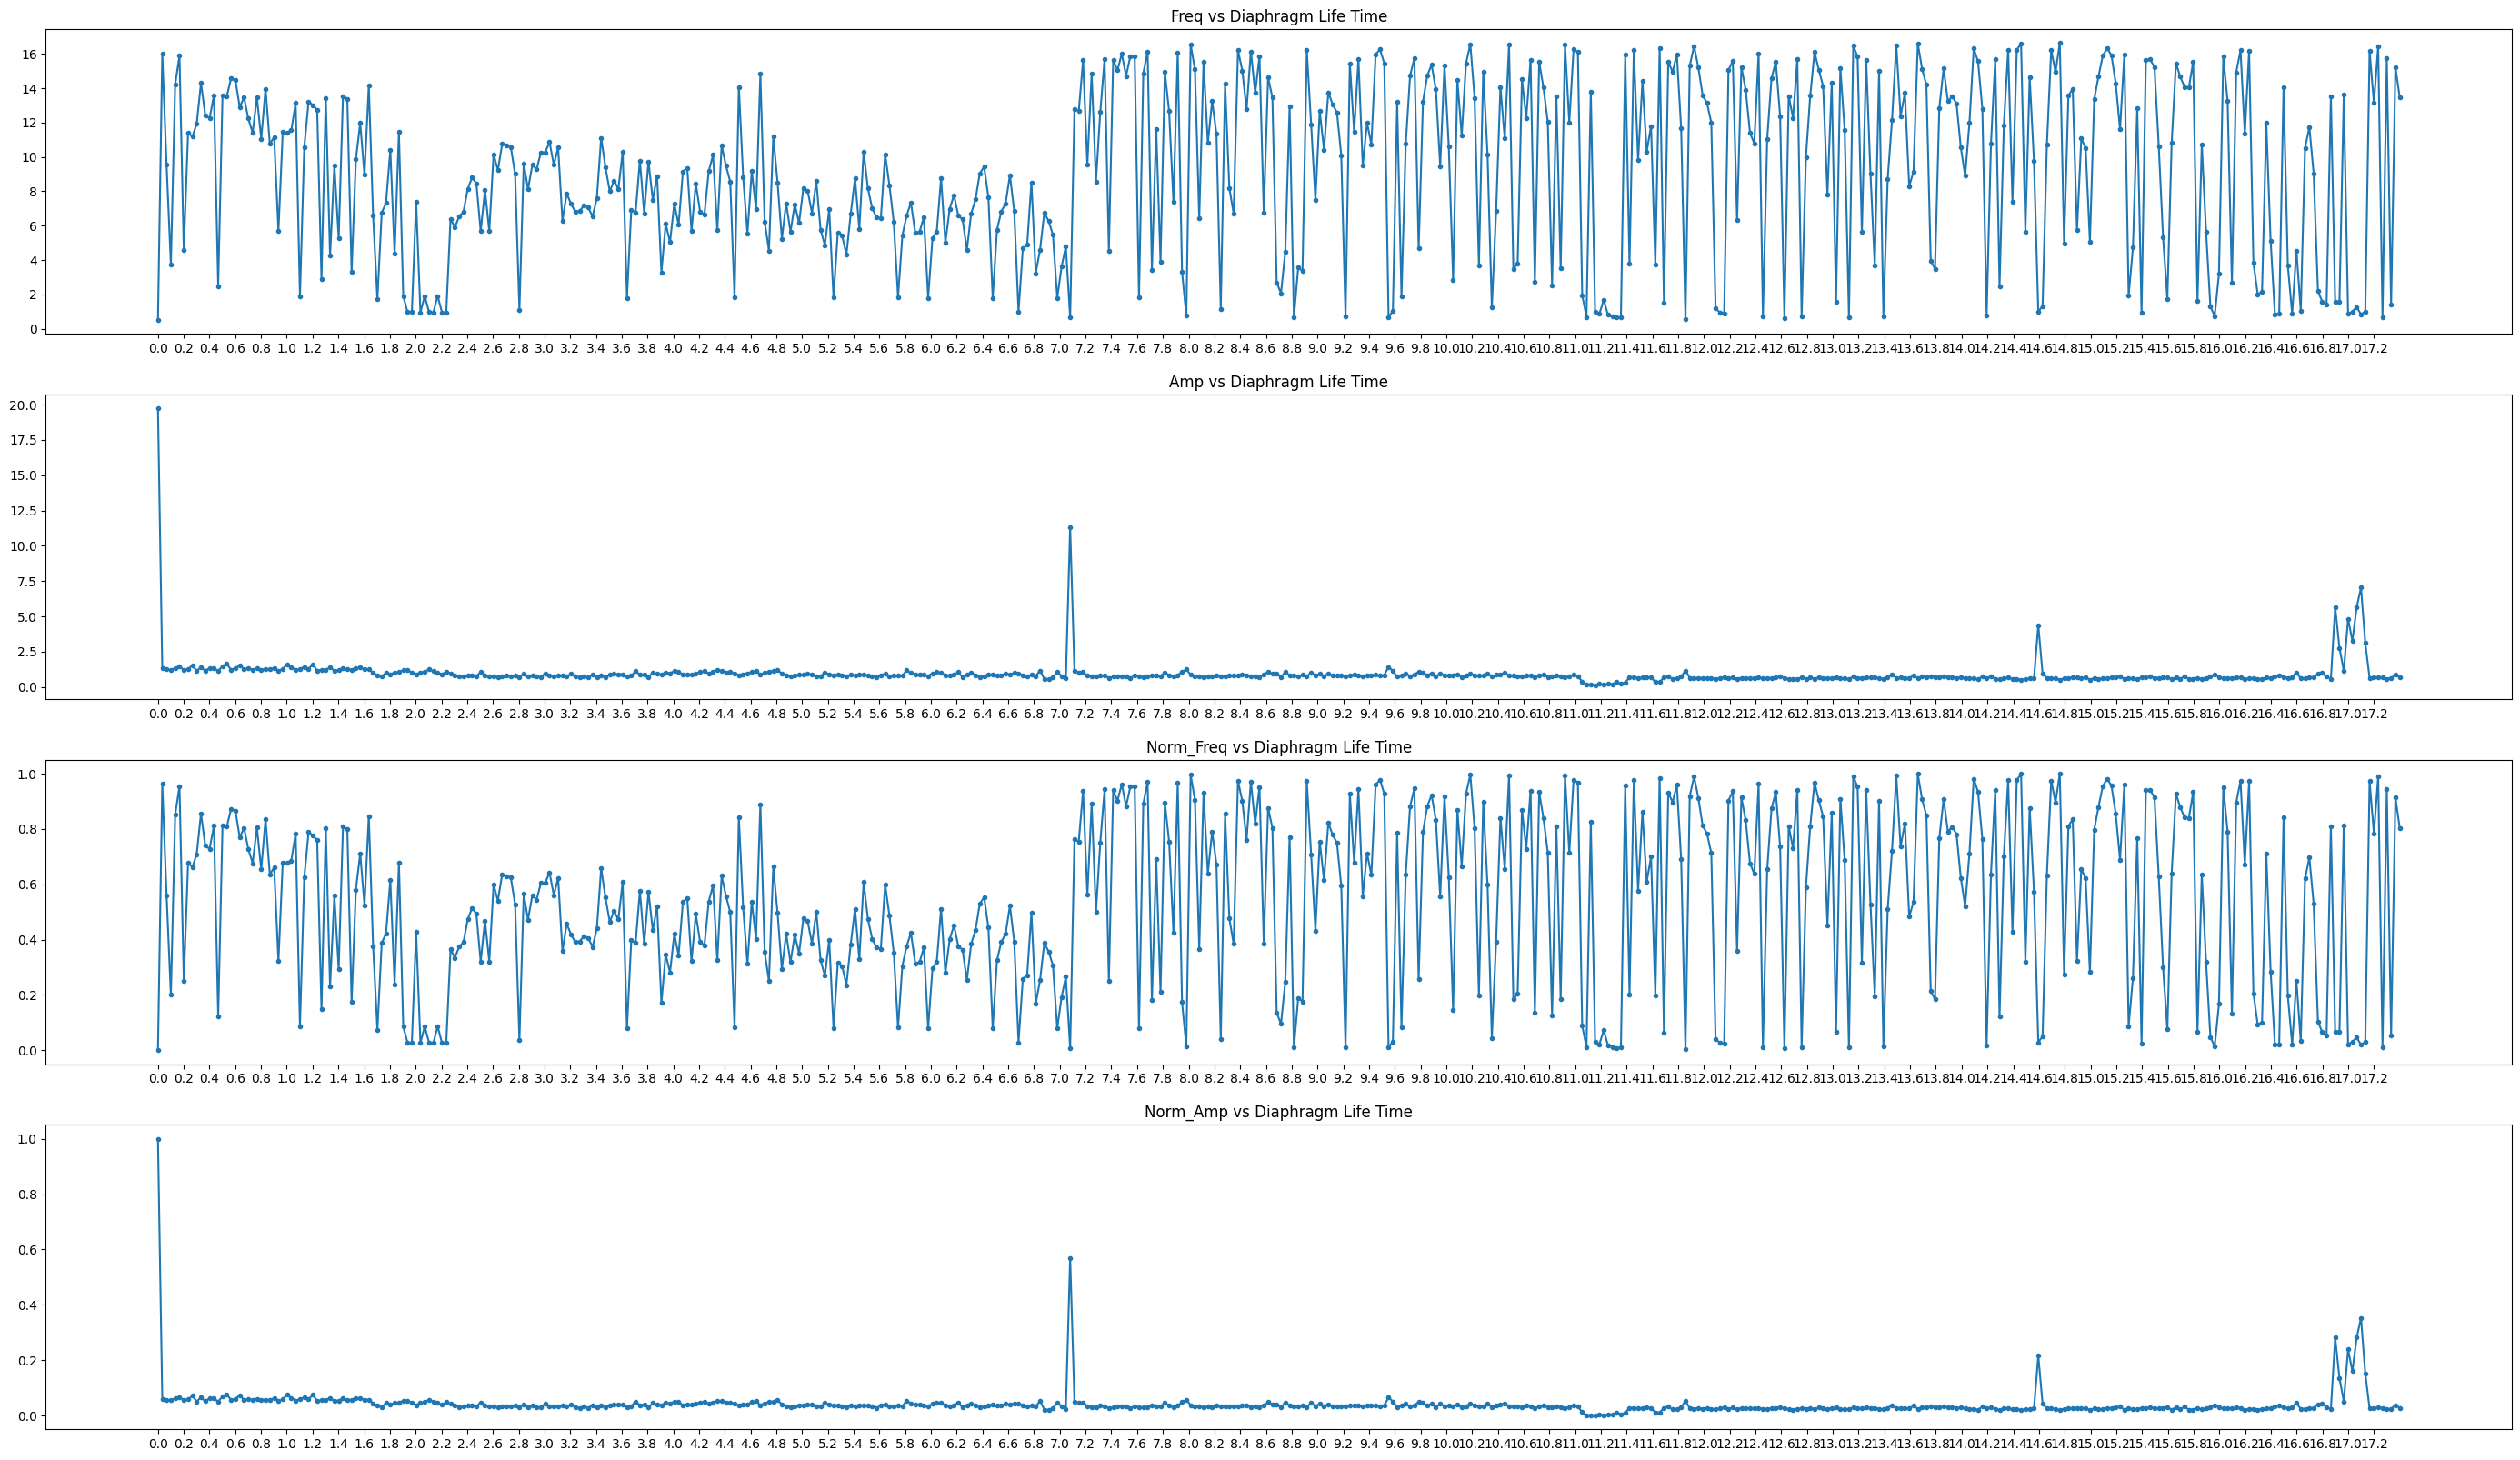

In [42]:
plot_funtion(Freq_Amp_df)

# RMS, Mean, Median Values

In [84]:
 
#temp_dic = {}
rms_list=[]
rms_median_df_good = pd.DataFrame(columns=['rms'])

start_time = Filter_data_df_good.index[0]
end_time = Filter_data_df_good.index[-1]
time_interval = pd.Timedelta(minutes=2)

current_time = start_time
while current_time <= end_time:
    
    next_time = current_time + time_interval
    
    # Slice the DataFrame based on the specified time range
    sliced_df = Filter_data_df_good.iloc[(Filter_data_df_good.index >= current_time) & (Filter_data_df_good.index <= next_time)]
    
    # Perform FFT analysis only if there is data in the sliced DataFrame
    n = len(sliced_df)
    if n > 0:
        #caluclate rms
        rms = np.sqrt(np.mean(sliced_df['Left-Vibration-Data']**2))
        
        #Append coresponding maximum amplitude frequency values in to freq_amp list
        #Freq_list.append((df_Filter['Frequency']))
        #Amp_list.append((df_Filter['Amplitude']))
        rms_list.append(rms)
                
    else:
        pass
    current_time = next_time    
#temp_dic[key] = result_df

# Append the DataFrame to the list
rms_median_df_good = pd.DataFrame({'rms':rms_list})

In [ ]:
#rms_median_df=rms_median_df[rms_median_df['rms']<67.9]

In [85]:
#Reset the data frame
rms_median_df_good.reset_index(drop=True,inplace=True)

#Normalize the data frame values
normalized_variables = MinMaxScaler().fit_transform(rms_median_df_good)

#Insert the normalized vaules in to the new columns
for value_index,col_name in enumerate(rms_median_df_good.columns):
    rms_median_df_good["Norm_{}".format(col_name)] = normalized_variables[:,value_index]

#Create diaprhagm liftime
timeline = [n for n in np.linspace(0,total_hrs_good,len(rms_median_df_good))]

#Insert timeline in to dataframe
rms_median_df_good['Diaphragm_life'] = timeline

#Set Diaphragm life as index
rms_median_df_good.set_index(['Diaphragm_life'],inplace=True)

# Cracked RMS

In [90]:
 
#temp_dic = {}
rms_list=[]
rms_median_df_cracked = pd.DataFrame(columns=['rms'])

start_time = Filter_data_df_cracked.index[0]
end_time = Filter_data_df_cracked.index[-1]
time_interval = pd.Timedelta(minutes=2)

current_time = start_time
while current_time <= end_time:
    
    next_time = current_time + time_interval
    
    # Slice the DataFrame based on the specified time range
    sliced_df = Filter_data_df_cracked.iloc[(Filter_data_df_cracked.index >= current_time) & (Filter_data_df_cracked.index <= next_time)]
    
    # Perform FFT analysis only if there is data in the sliced DataFrame
    n = len(sliced_df)
    if n > 0:
        #caluclate rms
        rms = np.sqrt(np.mean(sliced_df['Left-Vibration-Data']**2))
        
        #Append coresponding maximum amplitude frequency values in to freq_amp list
        #Freq_list.append((df_Filter['Frequency']))
        #Amp_list.append((df_Filter['Amplitude']))
        rms_list.append(rms)
                
    else:
        pass
    current_time = next_time    
#temp_dic[key] = result_df

# Append the DataFrame to the list
rms_median_df_cracked = pd.DataFrame({'rms':rms_list})

In [98]:
#Reset the data frame
rms_median_df_cracked.reset_index(drop=True,inplace=True)

#Normalize the data frame values
normalized_variables = MinMaxScaler().fit_transform(rms_median_df_cracked)

#Insert the normalized vaules in to the new columns
for value_index,col_name in enumerate(rms_median_df_cracked.columns):
    rms_median_df_cracked["Norm_{}".format(col_name)] = normalized_variables[:,value_index]

#Create diaprhagm liftime
timeline = [n for n in np.linspace(6.600000,16.6,len(rms_median_df_cracked))]

#Insert timeline in to dataframe
rms_median_df_cracked['Diaphragm_life'] = timeline

#Set Diaphragm life as index
rms_median_df_cracked.set_index(['Diaphragm_life'],inplace=True)

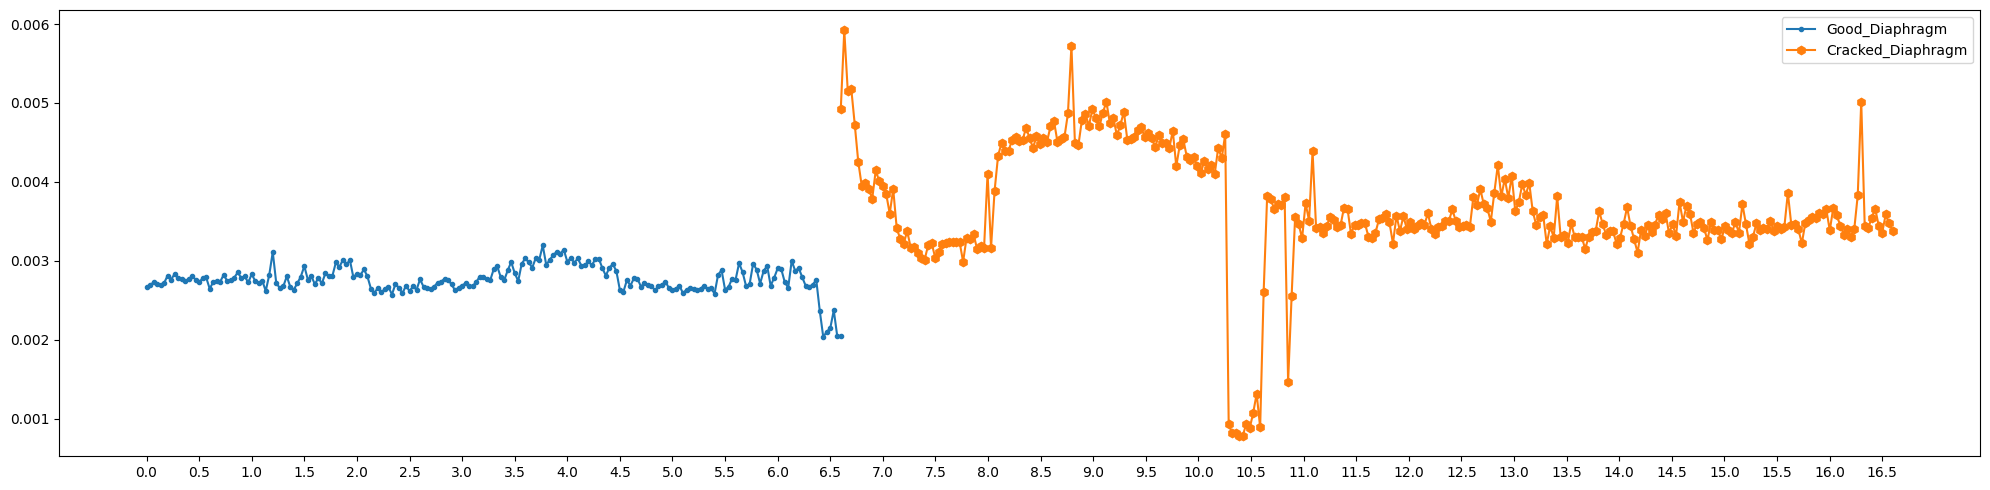

In [110]:
plt.figure(figsize=(20,5))
#plt.plot(cylinder_1_df.index, cylinder_1_df['PresTrans1'])
plt.plot(rms_median_df_good.index, rms_median_df_good['rms'],marker ='.')
plt.plot(rms_median_df_cracked.index, rms_median_df_cracked['rms'],marker='h')
plt.legend(['Good_Diaphragm', 'Cracked_Diaphragm'])
plt.xticks(np.arange(0,17,0.5))
plt.tight_layout()

In [116]:
merged_rms = pd.concat([rms_median_df_good,rms_median_df_cracked],ignore_index=True)

In [118]:
merged_rms['Timeline'] = np.linspace(0,16.6,len(merged_rms))

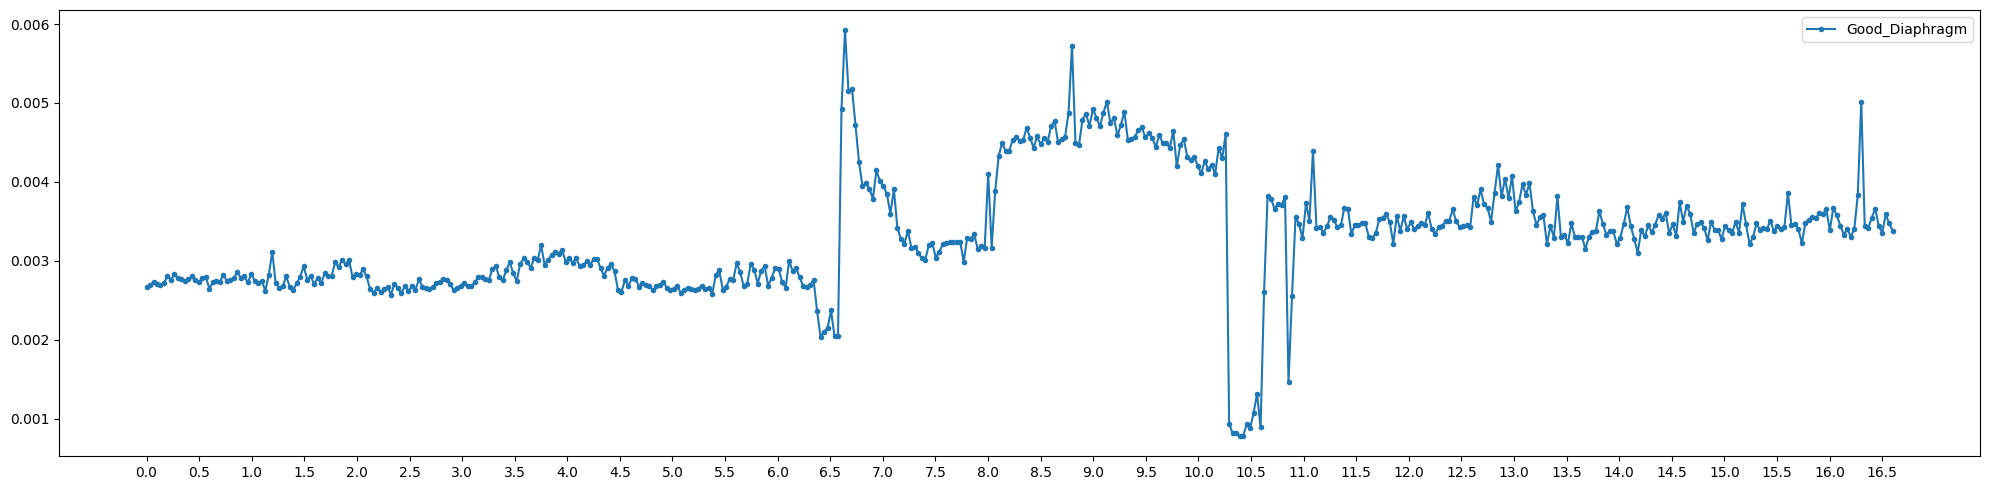

In [119]:
plt.figure(figsize=(20,5))
#plt.plot(cylinder_1_df.index, cylinder_1_df['PresTrans1'])
plt.plot(merged_rms['Timeline'], merged_rms['rms'],marker ='.')
#plt.plot(rms_median_df_cracked.index, rms_median_df_cracked['rms'],marker='h')
plt.legend(['Good_Diaphragm', 'Cracked_Diaphragm'])
plt.xticks(np.arange(0,17,0.5))
plt.tight_layout()